In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "201625864"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"])
df

,Model,Compression,BLEU
0,pythia-70M,Original,0.419960
1,pythia-70M,8-bit,0.413900
2,pythia-70M,4-bit,0.392100
3,pythia-70M,8-bit dyn.,0.359890
4,pythia-160M,Original,0.424930
5,pythia-160M,8-bit,0.423100
6,pythia-160M,4-bit,0.406040
7,pythia-160M,8-bit dyn.,0.380700
8,pythia-410M,Original,0.435090
9,pythia-410M,8-bit,0.436120


# RQ-4: Generalizibility check

## RQ-1: precision vs task performance

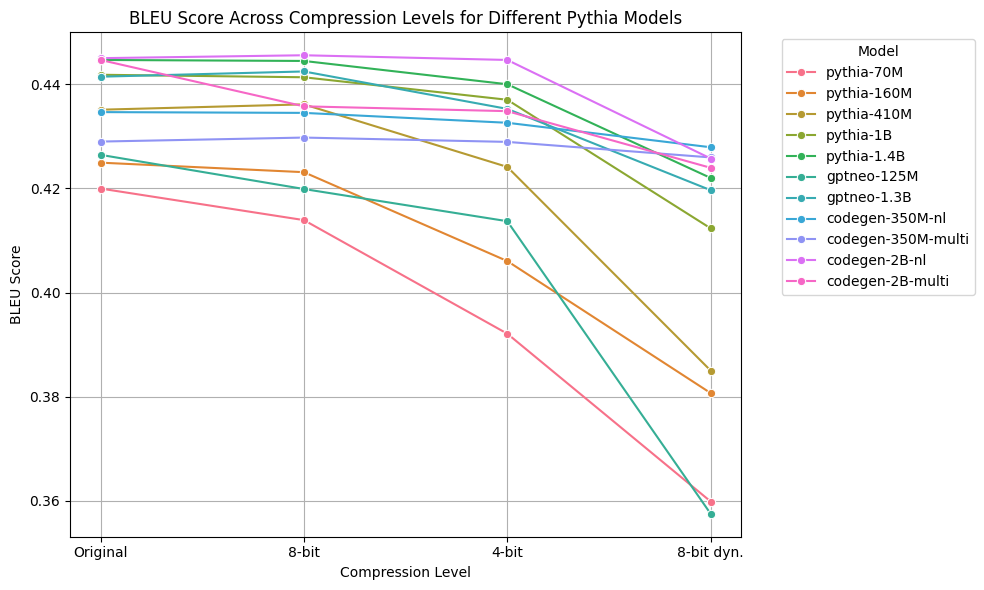

In [2]:
compression_order = ["Original", "8-bit", "4-bit", "8-bit dyn."]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o")

plt.title("BLEU Score Across Compression Levels for Different Pythia Models")
plt.ylabel("BLEU Score")
plt.xlabel("Compression Level")
# plt.ylim(0.38, 0.46)
plt.grid(True)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("./output/RQ-5.1.1.png", dpi=300, bbox_inches="tight")
plt.show()

## RQ-2: precision vs MIA

In [3]:
def graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-4.2.1.png"):
    compression_order = ["Original", "8-bit", "4-bit", "8-bit dyn."]
    df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Compression", y=score_col, hue="Model", marker="o")
    plt.title(f"{miaName}({score_col}) Score Across Compression Levels for Different Pythia Models")
    plt.ylabel(f"{score_col} Score")
    plt.xlabel("Compression Level")
    plt.grid(True)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"./output/{fileName}", dpi=300, bbox_inches="tight")
    plt.show()

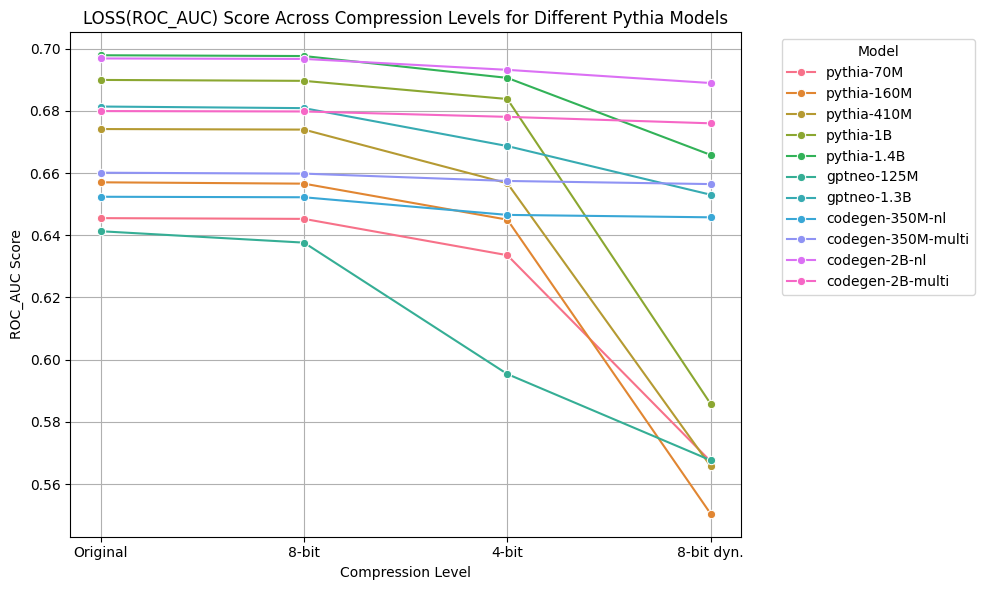

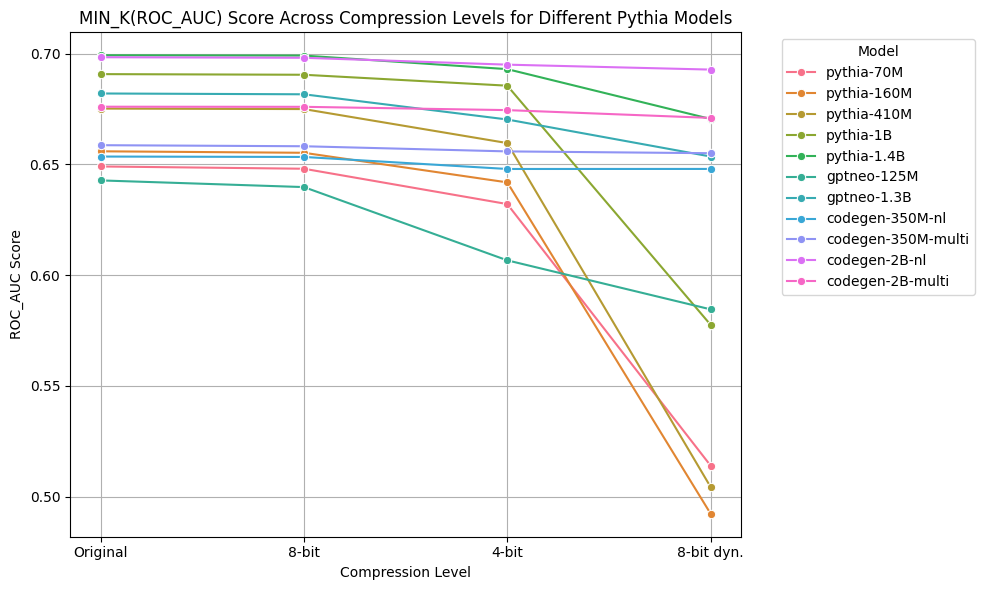

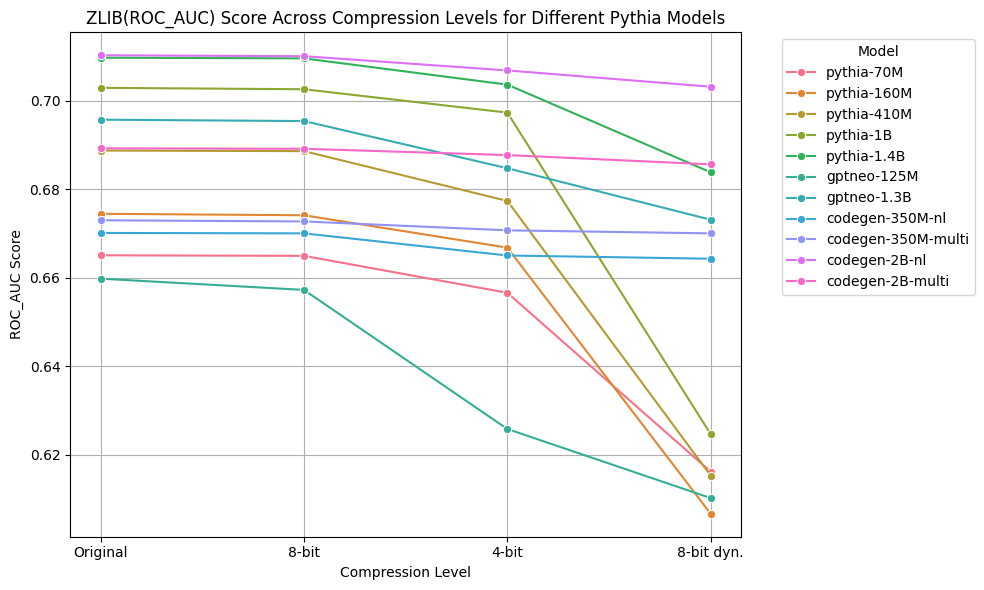

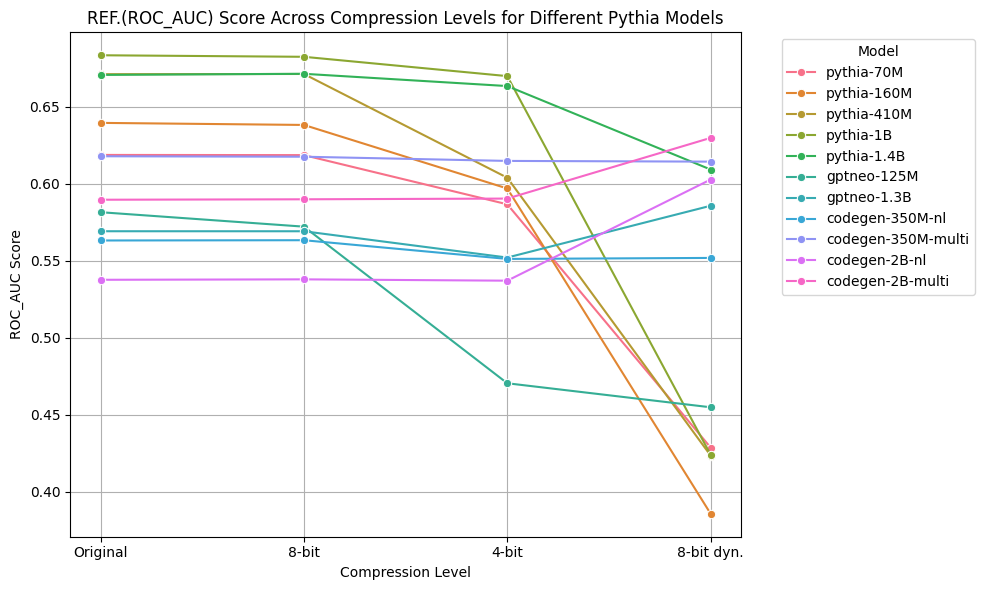

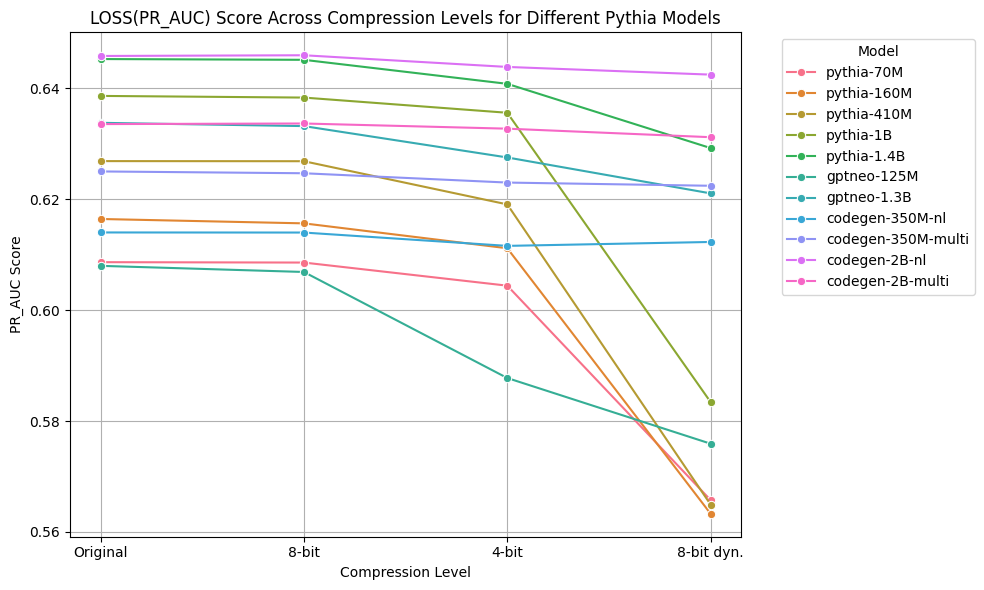

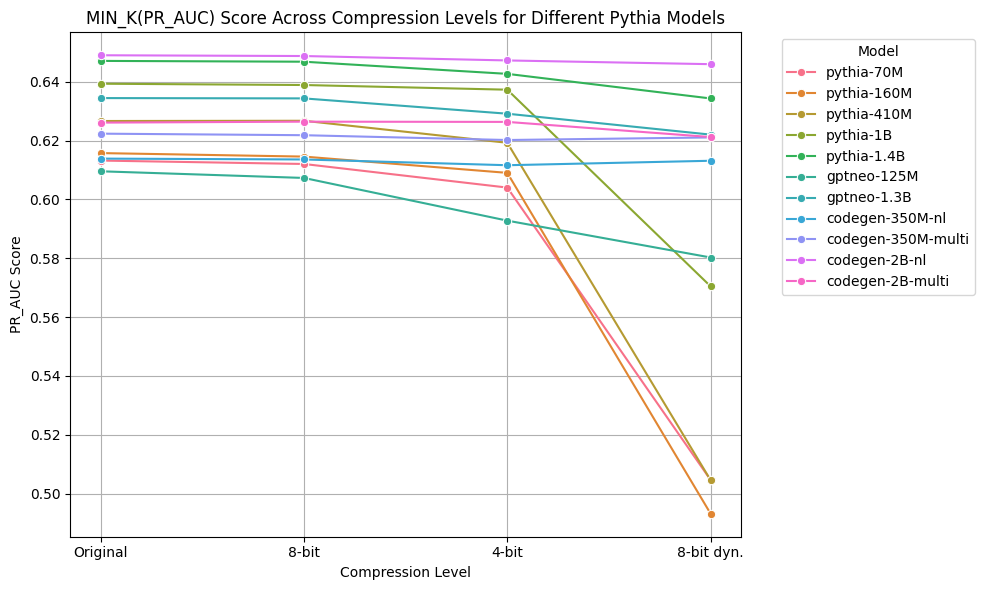

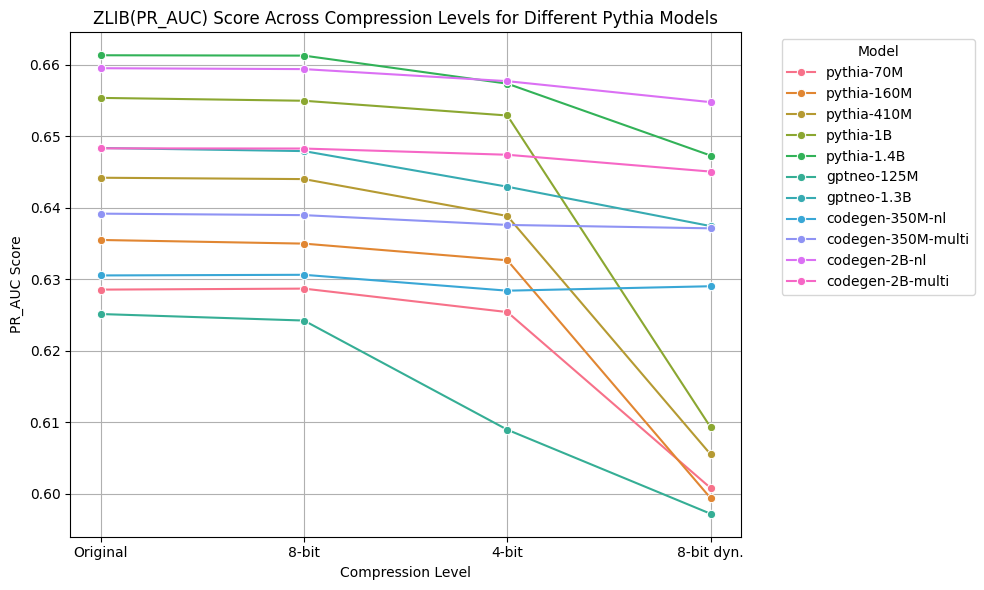

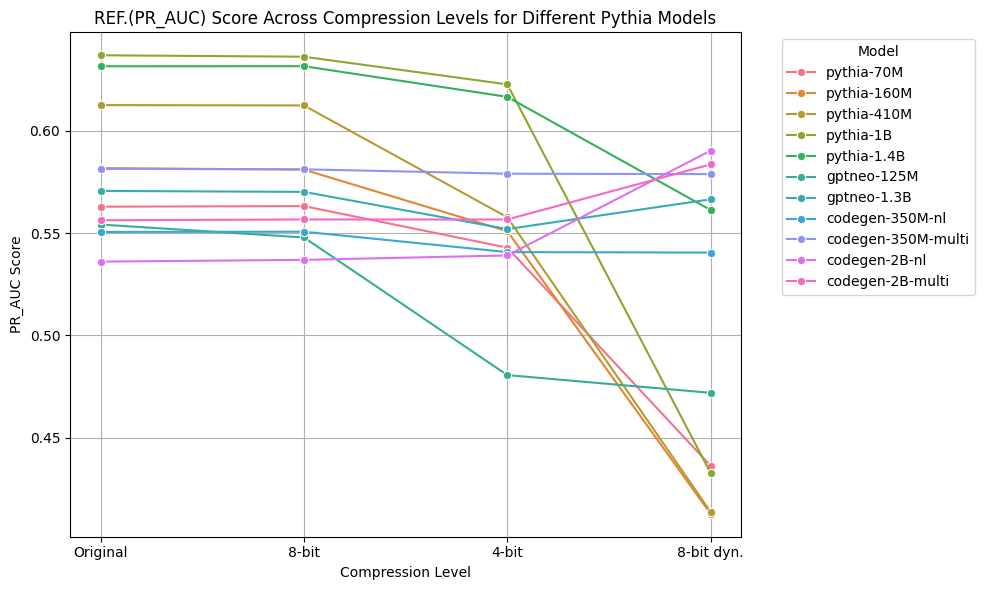

In [4]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC"])
graph_roc_auc(df, score_col="ROC_AUC", miaName="LOSS", fileName="RQ-5.2.1.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.1"])
df = df.rename(columns={"ROC_AUC.1": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="MIN_K", fileName="RQ-5.2.2.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.2"])
df = df.rename(columns={"ROC_AUC.2": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="ZLIB", fileName="RQ-5.2.3.png")
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "ROC_AUC.3"])

df = df.rename(columns={"ROC_AUC.3": "ROC_AUC"})
graph_roc_auc(df, score_col="ROC_AUC", miaName="REF.", fileName="RQ-5.2.4.png")


metric = "PR_AUC"

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", metric])
graph_roc_auc(df, score_col=metric, miaName="LOSS", fileName="RQ-5.2.5.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.1"])
df = df.rename(columns={"PR_AUC.1": metric})
graph_roc_auc(df, score_col=metric, miaName="MIN_K", fileName="RQ-5.2.6.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.2"])
df = df.rename(columns={"PR_AUC.2": metric})
graph_roc_auc(df, score_col=metric, miaName="ZLIB", fileName="RQ-5.2.7.png")

df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "PR_AUC.3"])
df = df.rename(columns={"PR_AUC.3": metric})
graph_roc_auc(df, score_col=metric, miaName="REF.", fileName="RQ-5.2.8.png")

## RQ-3: Correlation between task performance and MIA

In [5]:
df = pd.read_csv(full_url, skiprows=2)
df

,Model,Compression,Size (MB),BLEU,ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731840,0.419960,0.645490,0.608660,0.649060,0.613200,0.665050,0.628550,0.618670,0.562850
1,pythia-70M,8-bit,122.126910,0.413900,0.645250,0.608590,0.648030,0.612040,0.664920,0.628690,0.618550,0.563150
2,pythia-70M,4-bit,113.771070,0.392100,0.633570,0.604420,0.632080,0.604020,0.656570,0.625410,0.586590,0.542860
3,pythia-70M,8-bit dyn.,147.859950,0.359890,0.567270,0.565730,0.513980,0.504650,0.616140,0.600810,0.428530,0.436410
4,pythia-160M,Original,649.341190,0.424930,0.657010,0.616450,0.655900,0.615740,0.674430,0.635490,0.639490,0.581670
5,pythia-160M,8-bit,240.116640,0.423100,0.656575,0.615660,0.655230,0.614550,0.674100,0.634980,0.638150,0.580950
6,pythia-160M,4-bit,202.650480,0.406040,0.644996,0.611170,0.641870,0.609020,0.666780,0.632650,0.596860,0.550900
7,pythia-160M,8-bit dyn.,278.672340,0.380700,0.550431,0.563270,0.492280,0.493180,0.606610,0.599390,0.385530,0.412990
8,pythia-410M,Original,1621.430000,0.435090,0.674133,0.626890,0.675180,0.626640,0.688730,0.644190,0.671120,0.612440
9,pythia-410M,8-bit,509.700000,0.436120,0.673955,0.626870,0.674960,0.626720,0.688600,0.644000,0.671260,0.612260


In [6]:
def generate_graphs(taskPerformance, MIA_attack, MIA_score, i):
    model_order = ['pythia-1.4B', 'pythia-1B','pythia-410M','pythia-160M', 'pythia-70M', 'gptneo-1.3B', 'gptneo-125M', 'codegen-2B-multi', 'codegen-350M-multi', 'codegen-2B-nl', 'codegen-350M-nl']

    compression_order = ['Original', '8-bit', '4-bit', '8-bit dyn.']
    markers = {'Original': 'o', '8-bit': 's', '4-bit': '^', '8-bit dyn.': 'D'}
    colors = {
        'pythia-1.4B': 'green',
        'pythia-1B': 'orange',
        'pythia-410M': 'blue',
        'pythia-160M': 'purple',
        'pythia-70M': 'red',
        'gptneo-1.3B': 'brown',
        'gptneo-125M': 'pink',
        'codegen-2B-multi': 'cyan',
        'codegen-350M-multi': 'magenta',
        'codegen-2B-nl': 'lime',
        'codegen-350M-nl': 'yellow'
    }

    # Create the optimized visualization
    plt.figure(figsize=(10, 6))

    # Plot each point with model-specific color and compression-specific marker
    for model in model_order:
        for compression in compression_order:
            subset = df[(df['Model'] == model) & (df['Compression'] == compression)]
            if not subset.empty:
                plt.scatter(subset[taskPerformance], subset[MIA_score],
                        c=colors[model],
                        marker=markers[compression],
                        s=120,
                        alpha=0.8,
                        edgecolors='w',
                        linewidths=1)

    # Create custom legends
    from matplotlib.lines import Line2D

    # Model legend (color-coded)
    model_legend_elements = [Line2D([0], [0], marker='o', color='w', label=model,
                            markerfacecolor=colors[model], markersize=10) 
                            for model in model_order]

    # Compression legend (marker-coded)
    compression_legend_elements = [Line2D([0], [0], marker=markers[comp], color='w', label=comp,
                                markerfacecolor='gray', markersize=10)
                                for comp in compression_order]

    # Add legends
    first_legend = plt.legend(handles=model_legend_elements, title='Model Size',
                            loc='upper left', bbox_to_anchor=(.01, 1))
    plt.gca().add_artist(first_legend)
    plt.legend(handles=compression_legend_elements, title='Compression',
            loc='upper left', bbox_to_anchor=(.23, 1))
    # Add proper regression line
    sns.regplot(x=taskPerformance, y=MIA_score, data=df,
                scatter=False, ci=95,
                line_kws={'color':'black', 'alpha':0.2, 'linestyle':'--', 'label':'Linear fit (95% CI)'})

    corr = df[taskPerformance].corr(df[MIA_score])
    # Add correlation annotation
    # Compute suitable location dynamically
    x_pos = min(df[taskPerformance]) + 0.8 * (max(df[taskPerformance]) - min(df[taskPerformance]))
    y_pos = max(df[MIA_score]) - 0.7 * (max(df[MIA_score]) - min(df[MIA_score]))

    plt.annotate(f'Pearson r = {corr:.3f}\np < 0.001', 
                xy=(x_pos, y_pos), xycoords='data',
                fontsize=10, bbox=dict(boxstyle='round', alpha=0.2))
    # Labels and title
    plt.title(f'Correlation between Task Performance and {MIA_attack} MIA ({MIA_score.split(".")[0]})', pad=20)
    plt.xlabel('Task Performance (BLEU score)')
    plt.ylabel(f'MIA Score ({MIA_score.split(".")[0]})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'./output/RQ-5.3.{i}.png', dpi=300)
    plt.show()

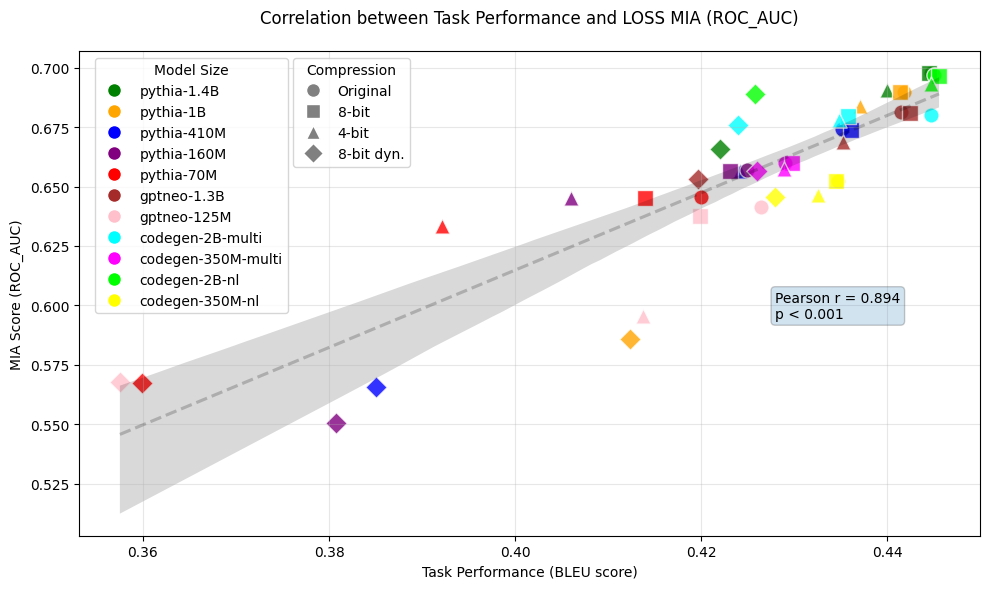

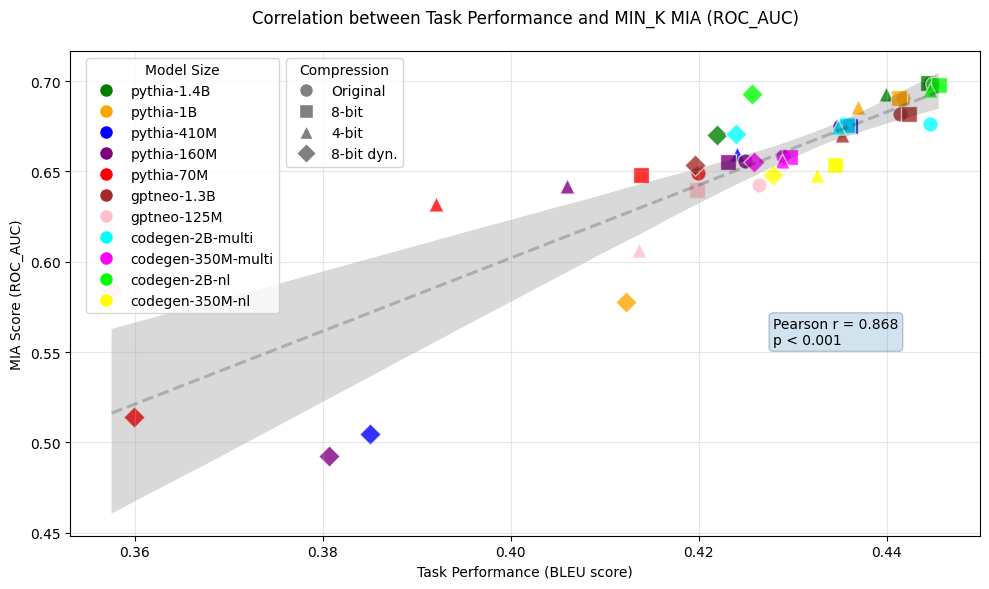

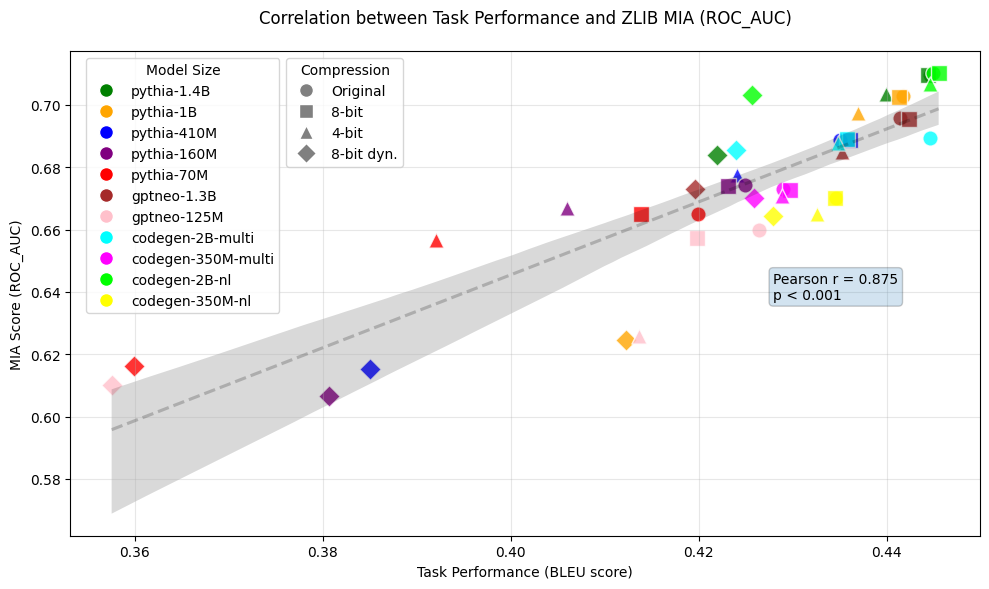

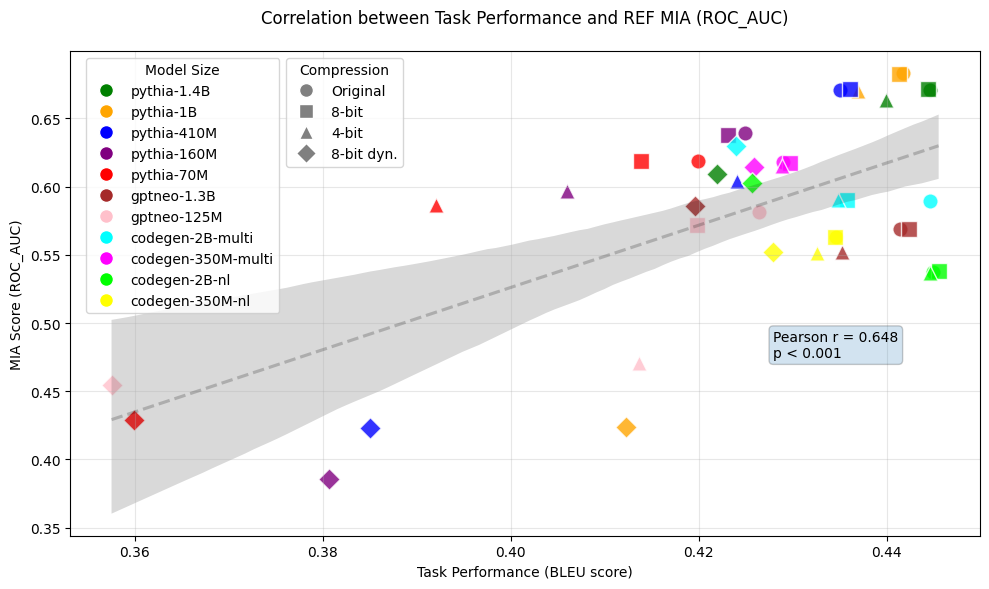

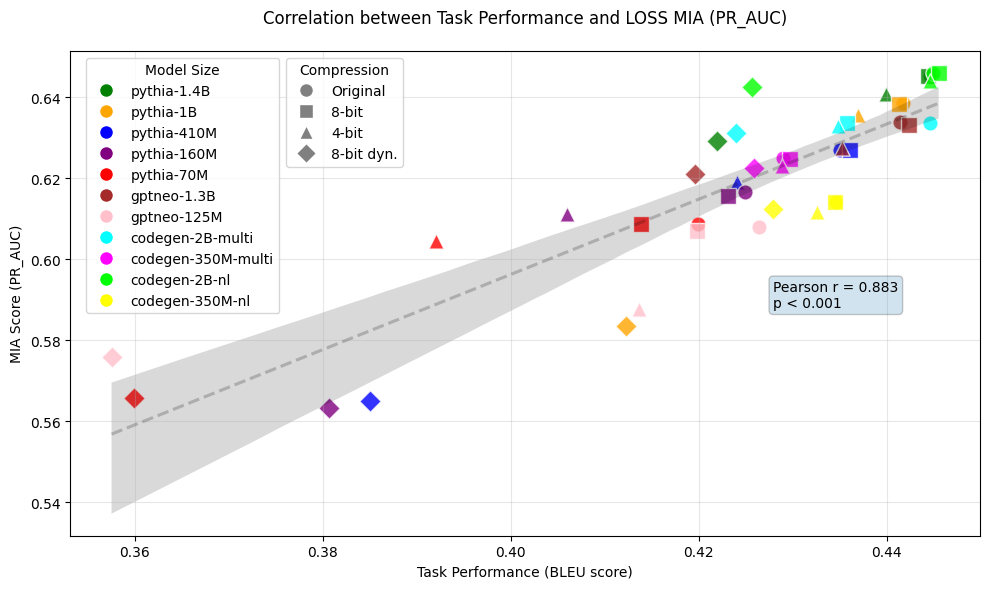

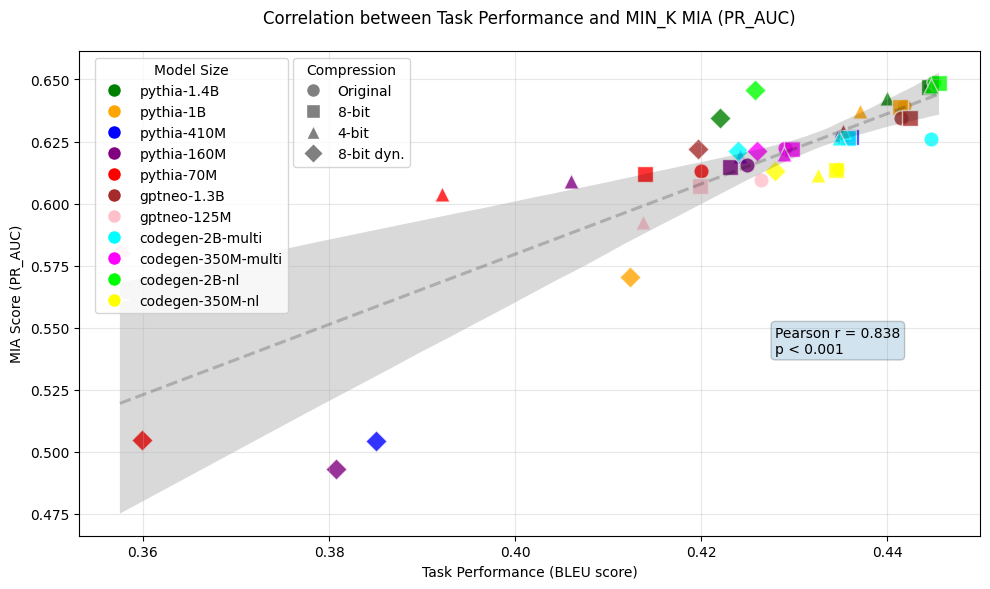

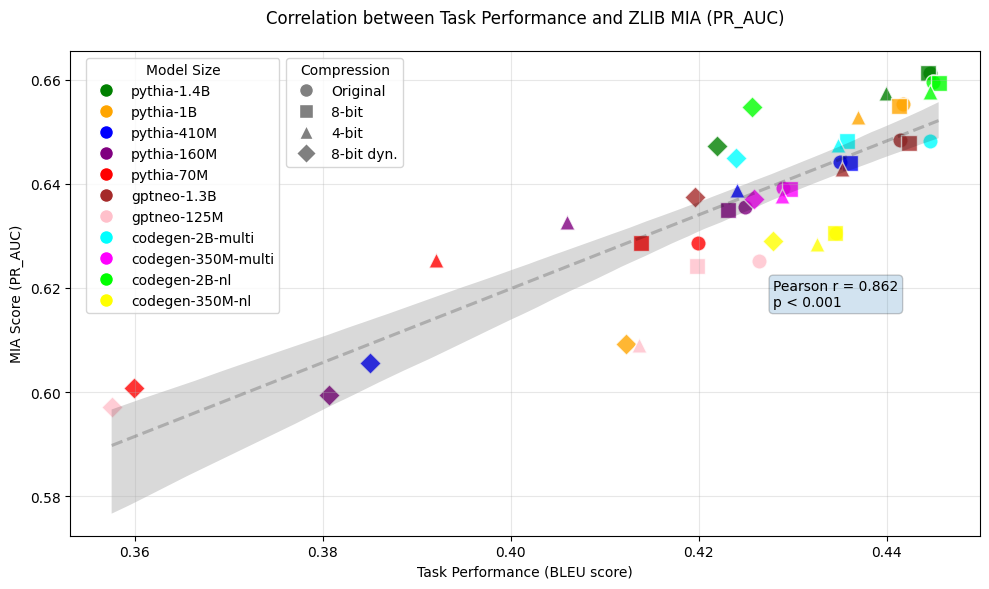

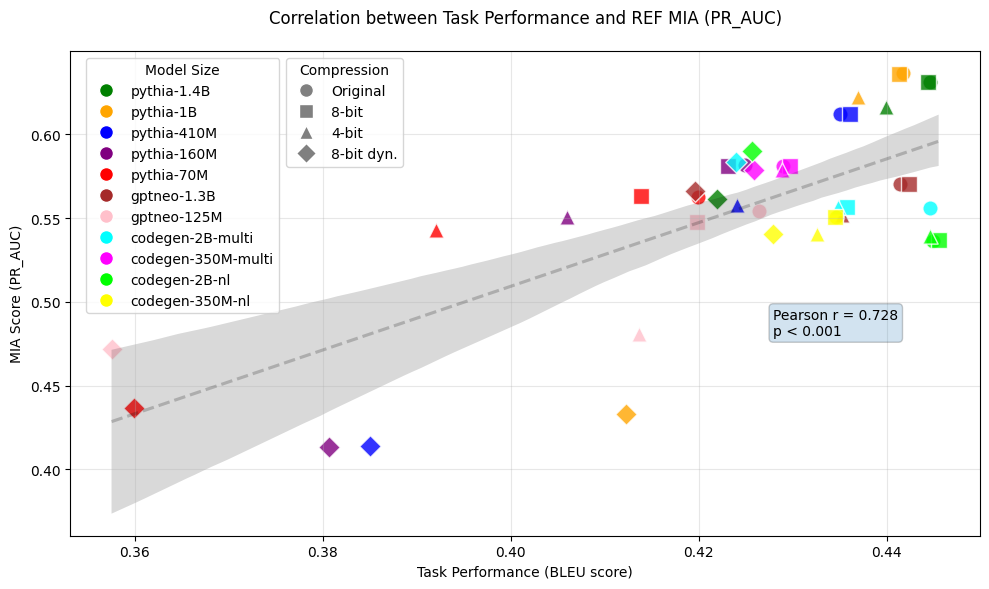

In [7]:
taskPerformance = "BLEU"
MIA_attacks = ["LOSS", "MIN_K", "ZLIB", "REF"]
MIA_scores = ["ROC_AUC", "ROC_AUC.1", "ROC_AUC.2", "ROC_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=1):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)


MIA_scores = ["PR_AUC", "PR_AUC.1", "PR_AUC.2", "PR_AUC.3"]
for i, (MIA_attack, MIA_score) in enumerate(zip(MIA_attacks, MIA_scores), start=5):
    generate_graphs(taskPerformance, MIA_attack, MIA_score, i)

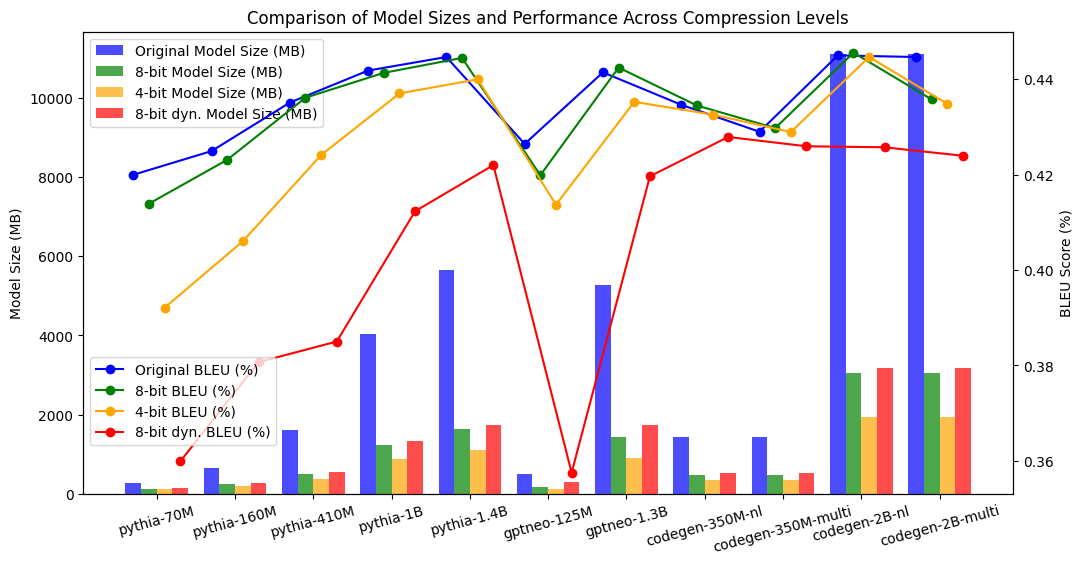

In [8]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "BLEU"])

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()

# Define bar width and colors
bar_width = 0.2
colors = ["blue", "green", "orange", "red"]

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for model sizes
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

ax1.set_ylabel("Model Size (MB)")
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, rotation=15)
ax1.legend(loc="upper left")

# Second y-axis for performance scores
ax2 = ax1.twinx()

# Plot line chart for performance
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(x + i * bar_width, subset["BLEU"], marker="o", linestyle="-", label=f"{comp} BLEU (%)", color=colors[i])

ax2.set_ylabel("BLEU Score (%)")
ax2.legend(loc="center left", bbox_to_anchor=(0, 0.2))

plt.title("Comparison of Model Sizes and Performance Across Compression Levels")
plt.savefig("BLEUvsModeSize.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "Size (MB)", "ROC_AUC", "PR_AUC", "ROC_AUC.1", "PR_AUC.1", "ROC_AUC.2", "PR_AUC.2", "ROC_AUC.3", "PR_AUC.3"])
df

,Model,Compression,Size (MB),ROC_AUC,PR_AUC,ROC_AUC.1,PR_AUC.1,ROC_AUC.2,PR_AUC.2,ROC_AUC.3,PR_AUC.3
0,pythia-70M,Original,281.731840,0.645490,0.608660,0.649060,0.613200,0.665050,0.628550,0.618670,0.562850
1,pythia-70M,8-bit,122.126910,0.645250,0.608590,0.648030,0.612040,0.664920,0.628690,0.618550,0.563150
2,pythia-70M,4-bit,113.771070,0.633570,0.604420,0.632080,0.604020,0.656570,0.625410,0.586590,0.542860
3,pythia-70M,8-bit dyn.,147.859950,0.567270,0.565730,0.513980,0.504650,0.616140,0.600810,0.428530,0.436410
4,pythia-160M,Original,649.341190,0.657010,0.616450,0.655900,0.615740,0.674430,0.635490,0.639490,0.581670
5,pythia-160M,8-bit,240.116640,0.656575,0.615660,0.655230,0.614550,0.674100,0.634980,0.638150,0.580950
6,pythia-160M,4-bit,202.650480,0.644996,0.611170,0.641870,0.609020,0.666780,0.632650,0.596860,0.550900
7,pythia-160M,8-bit dyn.,278.672340,0.550431,0.563270,0.492280,0.493180,0.606610,0.599390,0.385530,0.412990
8,pythia-410M,Original,1621.430000,0.674133,0.626890,0.675180,0.626640,0.688730,0.644190,0.671120,0.612440
9,pythia-410M,8-bit,509.700000,0.673955,0.626870,0.674960,0.626720,0.688600,0.644000,0.671260,0.612260


In [10]:
def genGraph(df, miaName):
    scoreName = df.columns[3].split(".")[0]
    # Extract unique model names
    models = df["Model"].unique()
    compressions = df["Compression"].unique()

    # Define bar width and colors
    bar_width = 0.2
    colors = ["blue", "green", "orange", "red"]

    x = np.arange(len(models))  # X-axis positions

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot bar chart for model sizes
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax1.bar(x + i * bar_width, subset["Size (MB)"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

    ax1.set_ylabel("Model Size (MB)")
    ax1.set_xticks(x + bar_width * 1.5)
    ax1.set_xticklabels(models, rotation=15)
    ax1.legend(loc="upper left")

    # Second y-axis for performance scores
    ax2 = ax1.twinx()

    # Plot line chart for performance
    for i, comp in enumerate(compressions):
        subset = df[df["Compression"] == comp]
        ax2.plot(x + i * bar_width, subset.iloc[:,3], marker="o", linestyle="-", label=f"{comp} {scoreName} ({miaName}) (%)", color=colors[i])

    ax2.set_ylabel(f"{scoreName} ({miaName}) (%)")
    ax2.legend(loc="center left", bbox_to_anchor=(0, 0.3))
    # ax2.legend(loc="upper right")

    plt.title(f"Comparison of Model Sizes and MIA ({miaName}) Across Compression Levels")
    plt.savefig(f"./output/{scoreName}({miaName}).png", dpi=300, bbox_inches="tight")
    plt.show()

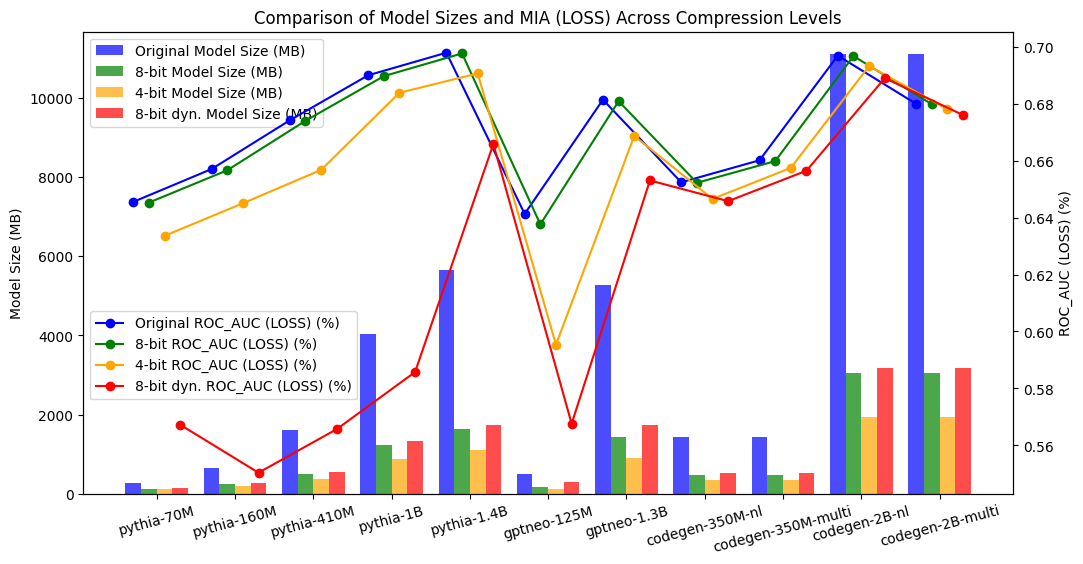

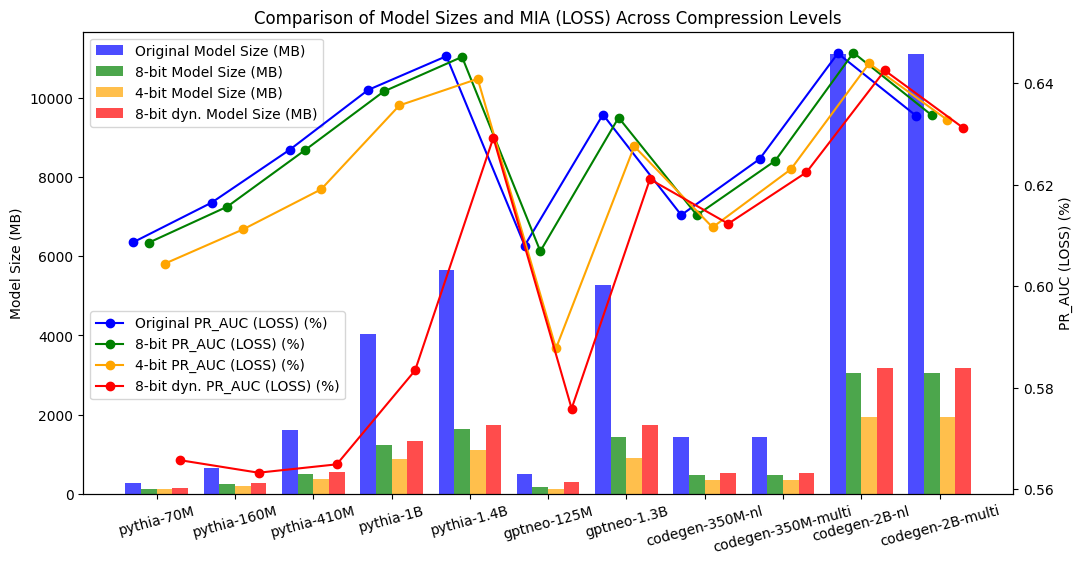

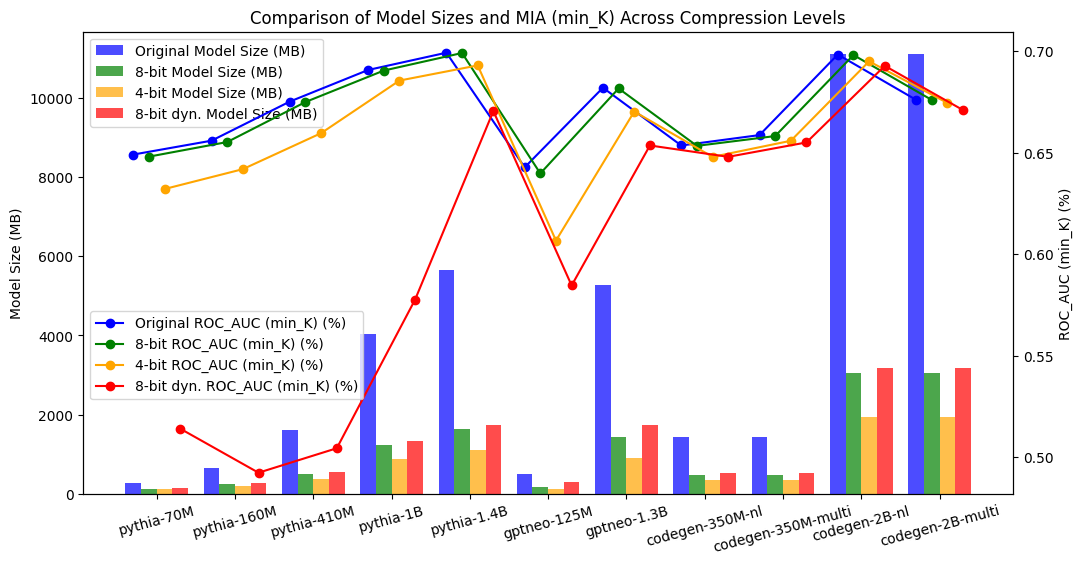

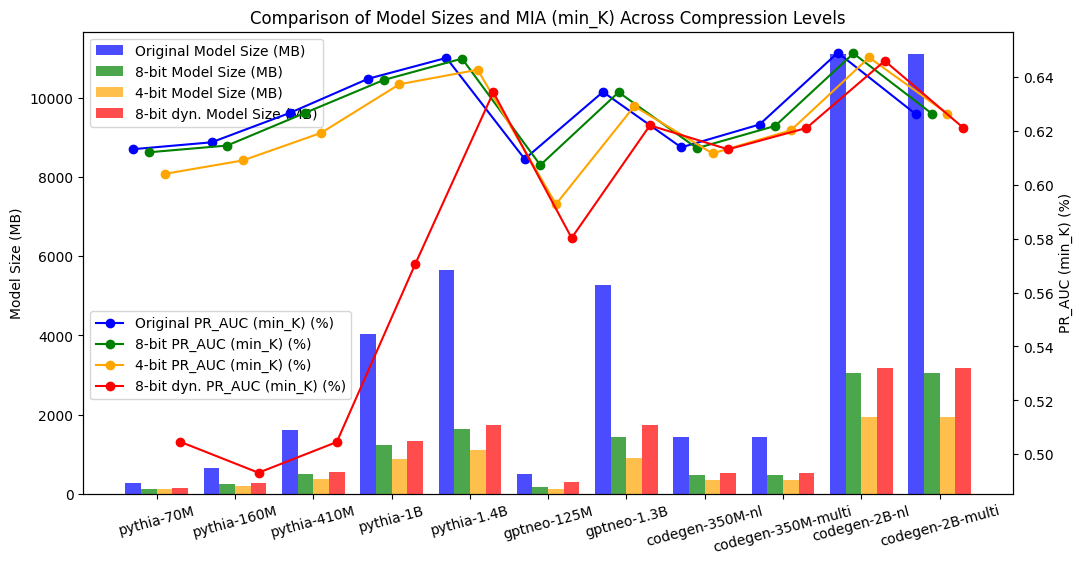

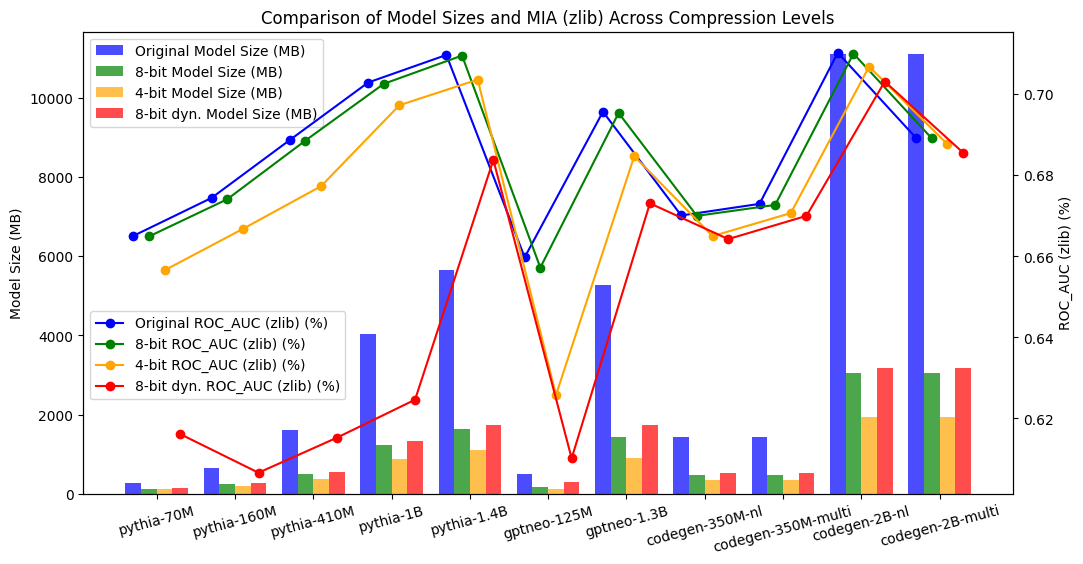

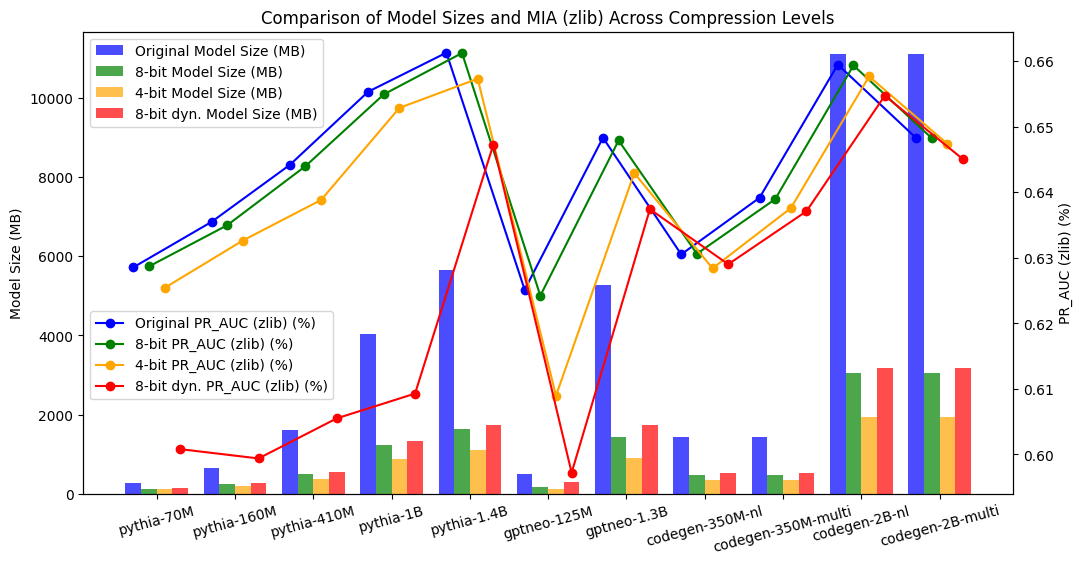

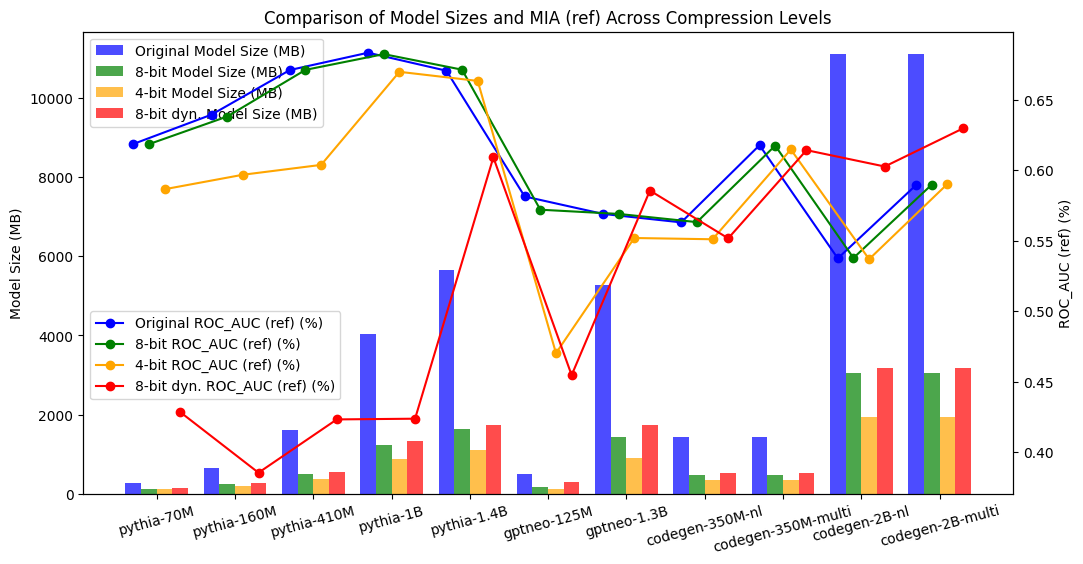

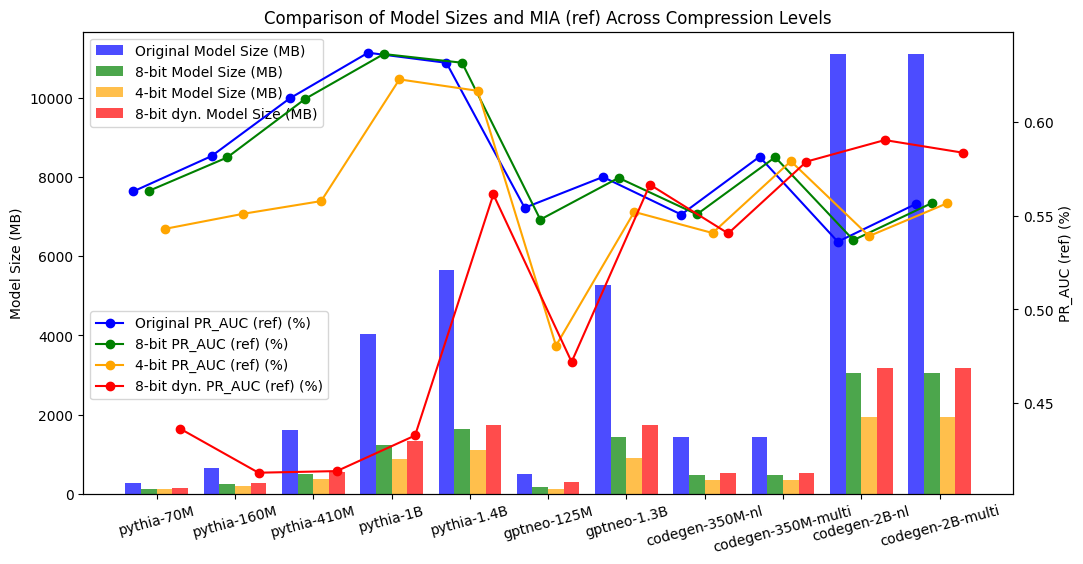

In [11]:
genGraph(df.iloc[:, [0,1,2,3]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,4]], miaName="LOSS")
genGraph(df.iloc[:, [0,1,2,5]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,6]], miaName="min_K")
genGraph(df.iloc[:, [0,1,2,7]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,8]], miaName="zlib")
genGraph(df.iloc[:, [0,1,2,9]], miaName="ref")
genGraph(df.iloc[:, [0,1,2,10]], miaName="ref")

## MIA VS TASK

In [12]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU", "ROC_AUC"]).iloc[:20, :]
df['ROC_AUC'] *=-1
df

,Model,Compression,BLEU,ROC_AUC
0,pythia-70M,Original,0.41996,-0.645490
1,pythia-70M,8-bit,0.41390,-0.645250
2,pythia-70M,4-bit,0.39210,-0.633570
3,pythia-70M,8-bit dyn.,0.35989,-0.567270
4,pythia-160M,Original,0.42493,-0.657010
5,pythia-160M,8-bit,0.42310,-0.656575
6,pythia-160M,4-bit,0.40604,-0.644996
7,pythia-160M,8-bit dyn.,0.38070,-0.550431
8,pythia-410M,Original,0.43509,-0.674133
9,pythia-410M,8-bit,0.43612,-0.673955


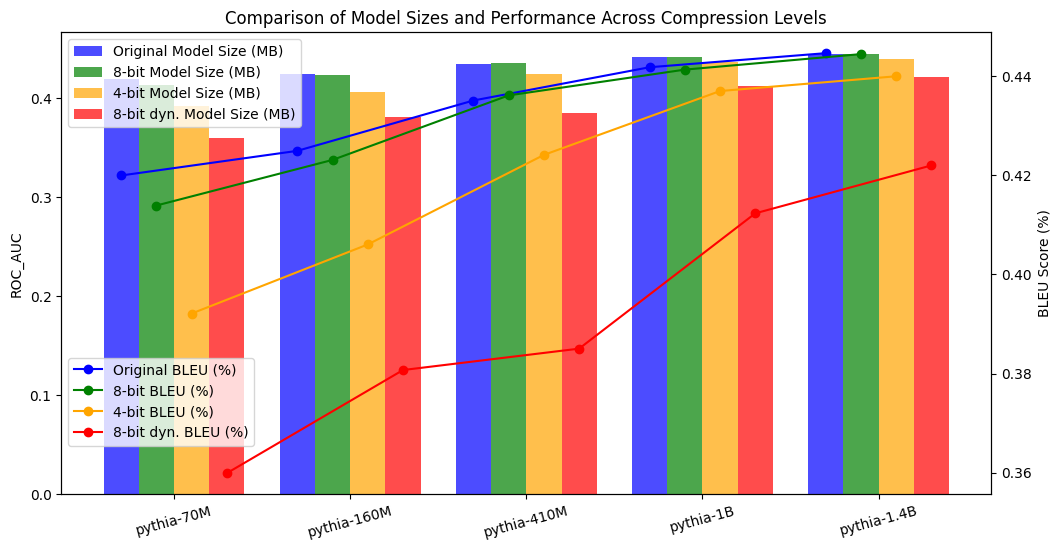

In [13]:

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()

# Define bar width and colors
bar_width = 0.2
colors = ["blue", "green", "orange", "red"]

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for model sizes
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax1.bar(x + i * bar_width, subset["BLEU"], width=bar_width, label=f"{comp} Model Size (MB)", alpha=0.7, color=colors[i])

ax1.set_ylabel("ROC_AUC")
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, rotation=15)
ax1.legend(loc="upper left")

# Second y-axis for performance scores
ax2 = ax1.twinx()

# Plot line chart for performance
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(x + i * bar_width, subset["BLEU"], marker="o", linestyle="-", label=f"{comp} BLEU (%)", color=colors[i])

ax2.set_ylabel("BLEU Score (%)")
ax2.legend(loc="center left", bbox_to_anchor=(0, 0.2))

plt.title("Comparison of Model Sizes and Performance Across Compression Levels")
plt.savefig("./output/BLEUvsMIA.png", dpi=300, bbox_inches="tight")
plt.show()

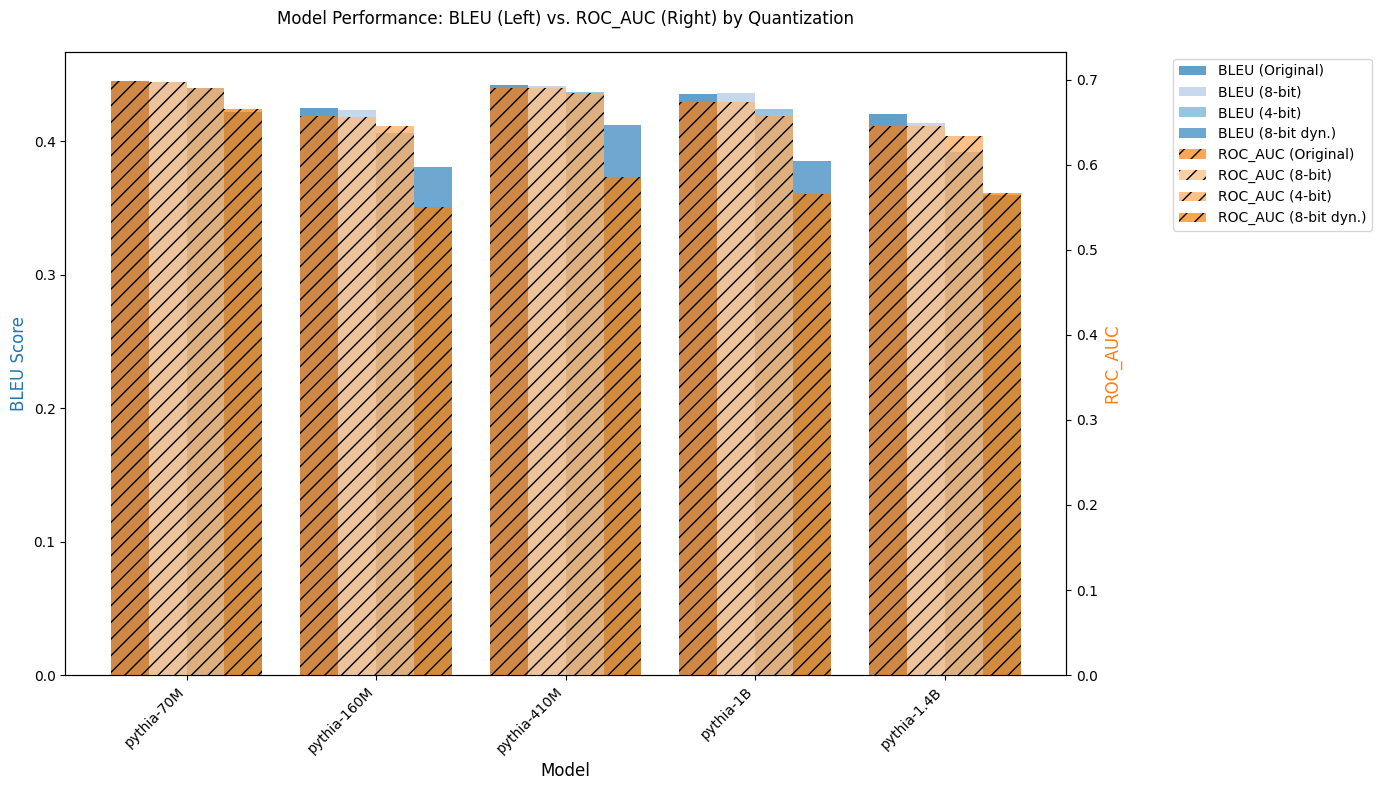

In [14]:
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU", "ROC_AUC"]).iloc[:20, :]
# df['ROC_AUC'] *=-1

# Pivot the data for plotting
pivot_df = df.pivot(index="Model", columns="Compression", values=["BLEU", "ROC_AUC"])

# Plot setup
fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# X-axis positions
models = df["Model"].unique()
x = np.arange(len(models))
width = 0.2  # Width of each bar

# Colors
colors_bleu = ['#1f77b4', '#aec7e8', '#6baed6', '#3182bd']  # Blues for BLEU
colors_auc = ['#ff7f0e', '#ffbb78', '#ffa756', '#ff8000']   # Oranges for ROC_AUC

# Plot BLEU (left axis)
for i, compression in enumerate(["Original", "8-bit", "4-bit", "8-bit dyn."]):
    ax1.bar(
        x + i * width,
        pivot_df["BLEU"][compression],
        width=width,
        color=colors_bleu[i],
        label=f"BLEU ({compression})",
        alpha=0.7
    )

# Plot ROC_AUC (right axis)
for i, compression in enumerate(["Original", "8-bit", "4-bit", "8-bit dyn."]):
    ax2.bar(
        x + i * width,
        pivot_df["ROC_AUC"][compression],
        width=width,
        color=colors_auc[i],
        label=f"ROC_AUC ({compression})",
        alpha=0.7,
        hatch="//"  # Add pattern to distinguish from BLEU
    )

# Axis labels and titles
ax1.set_xlabel("Model", fontsize=12)
ax1.set_ylabel("BLEU Score", fontsize=12, color='#1f77b4')
ax2.set_ylabel("ROC_AUC", fontsize=12, color='#ff7f0e')
ax1.set_xticks(x + 1.5 * width)
ax1.set_xticklabels(models, rotation=45, ha="right")
plt.title("Model Performance: BLEU (Left) vs. ROC_AUC (Right) by Quantization", pad=20)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_65180/2061927539.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


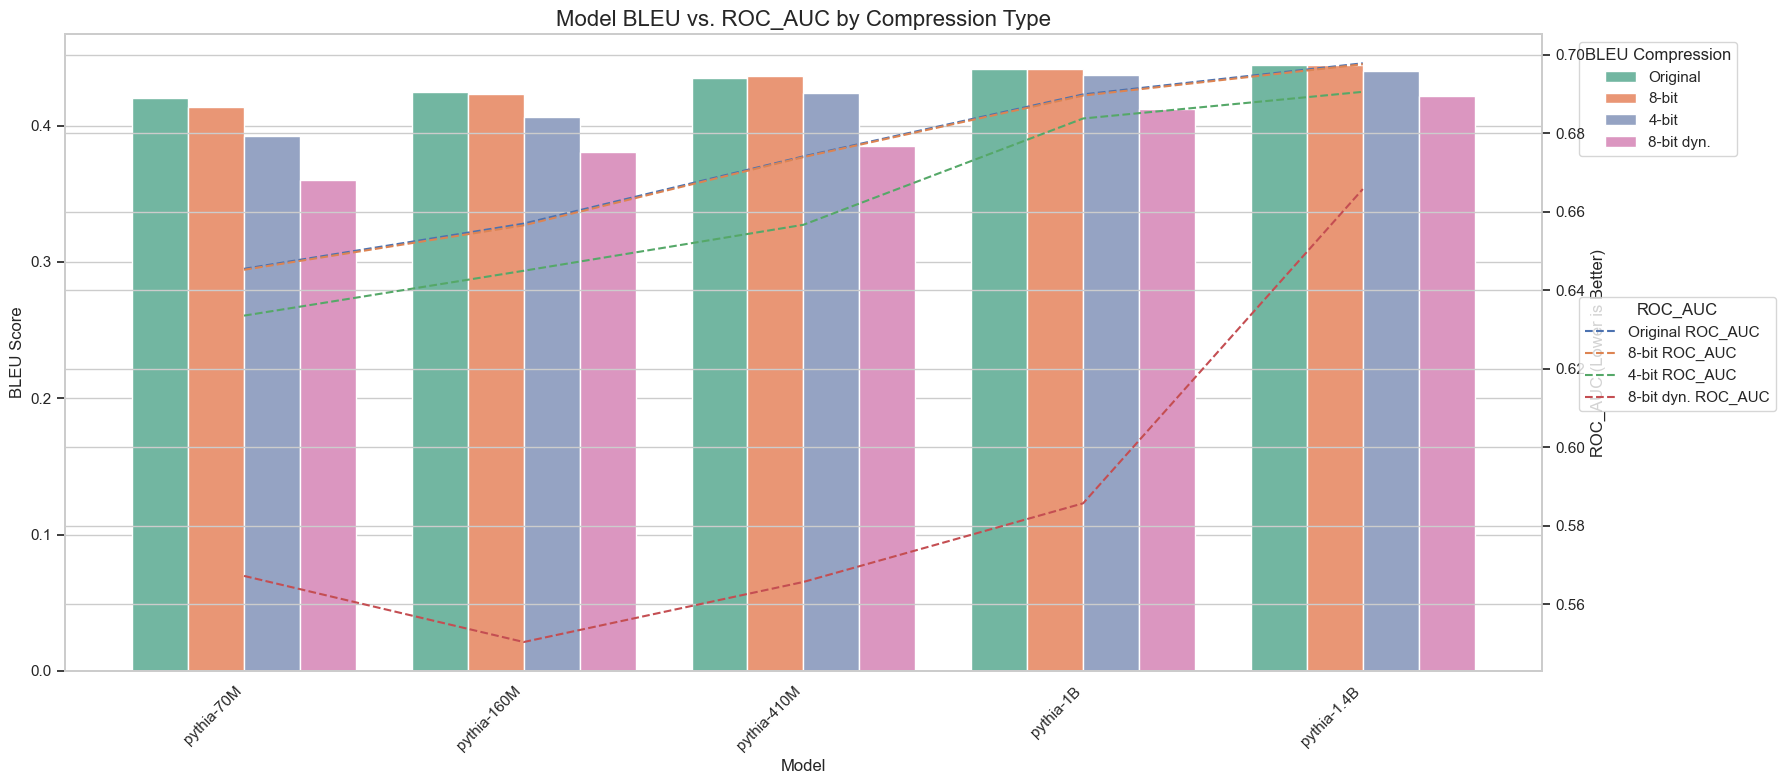

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot
plt.figure(figsize=(18, 8))
sns.set(style="whitegrid")

# Barplot for BLEU
ax = sns.barplot(data=df, x="Model", y="BLEU", hue="Compression", palette="Set2")

# Secondary axis for ROC_AUC
ax2 = ax.twinx()

# Line plot for ROC_AUC
for compression in df["Compression"].unique():
    subset = df[df["Compression"] == compression]
    ax2.plot(subset["Model"].values, subset["ROC_AUC"].values, label=f"{compression} ROC_AUC", linestyle='--')

# Formatting
ax.set_ylabel("BLEU Score")
ax2.set_ylabel("ROC_AUC (Lower is Better)")
ax.set_title("Model BLEU vs. ROC_AUC by Compression Type", fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="BLEU Compression")
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 0.6), title="ROC_AUC")

plt.tight_layout()
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_65180/3822000983.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


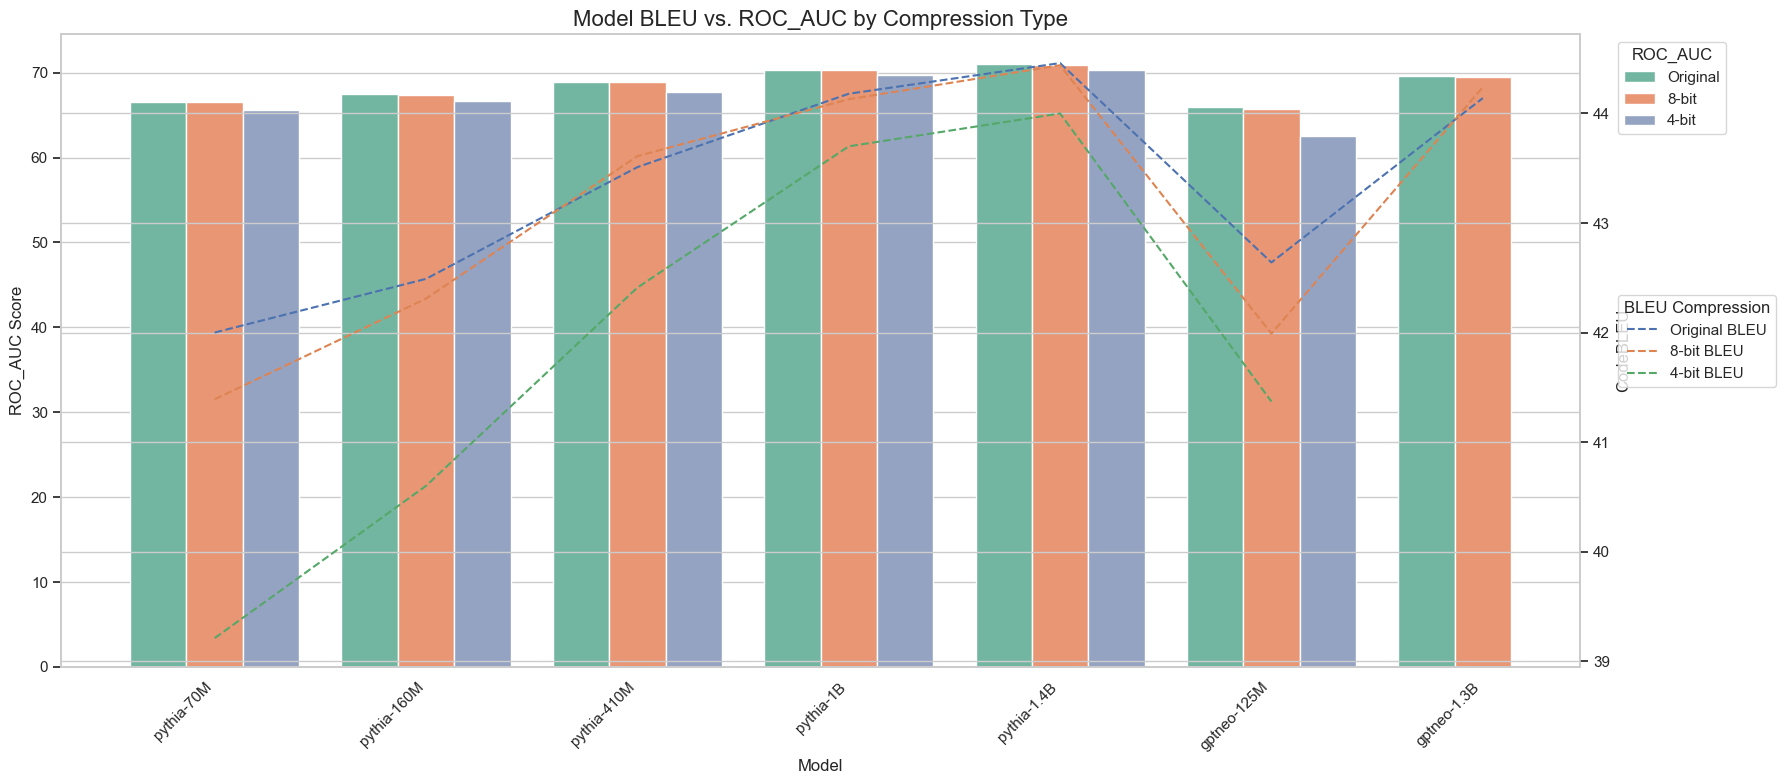

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
tab_gid = "1990888583"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU", "ROC_AUC.2"]).iloc[:20, :]

# Set up plot
plt.figure(figsize=(18, 8))
sns.set(style="whitegrid")

# Barplot for BLEU
ax = sns.barplot(data=df, x="Model", y="ROC_AUC.2", hue="Compression", palette="Set2")

# Secondary axis for ROC_AUC
ax2 = ax.twinx()

# Line plot for ROC_AUC
for compression in df["Compression"].unique():
    subset = df[df["Compression"] == compression]
    ax2.plot(subset["Model"].values, subset["BLEU"].values, label=f"{compression} BLEU", linestyle='--')

# Formatting
ax.set_ylabel("ROC_AUC Score")
ax2.set_ylabel("CodeBLEU")
ax.set_title("Model BLEU vs. ROC_AUC by Compression Type", fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="ROC_AUC")
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 0.6), title="BLEU Compression")

plt.tight_layout()
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_65180/3981829332.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=16)


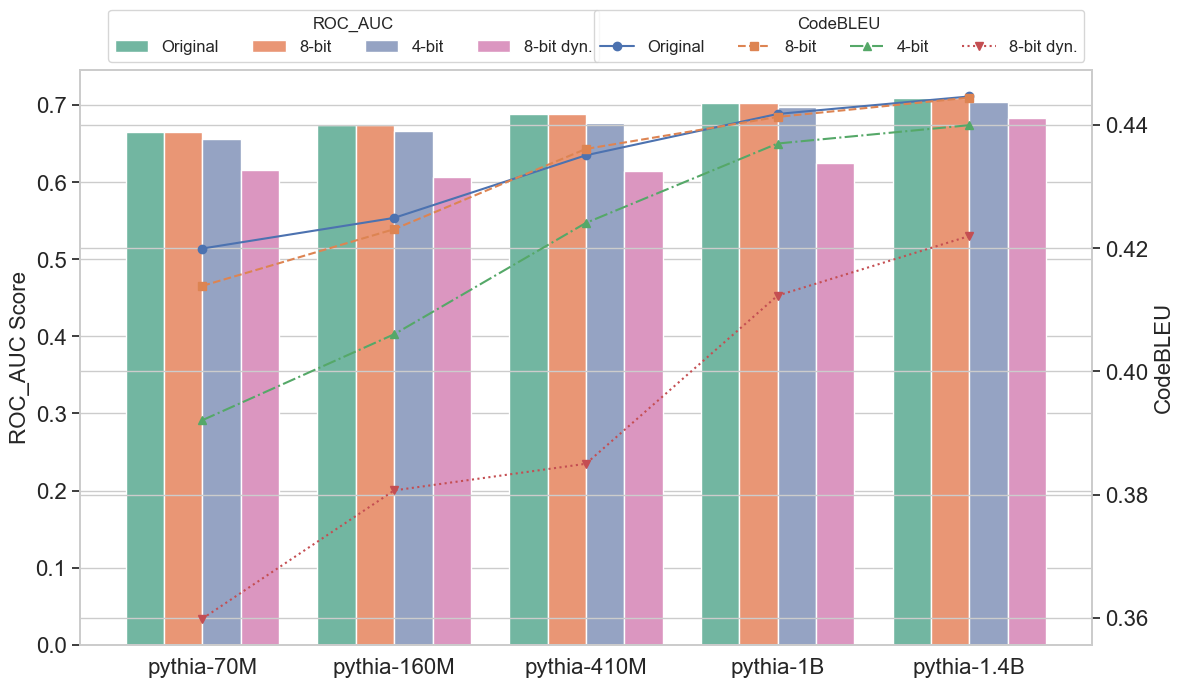

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
tab_gid = "201625864"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU", "ROC_AUC.2"]).iloc[:20, :]

# Set up plot
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")

# Barplot for BLEU
ax = sns.barplot(data=df, x="Model", y="ROC_AUC.2", hue="Compression", palette="Set2")

# Secondary axis for ROC_AUC
ax2 = ax.twinx()
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'v']
# Line plot for ROC_AUC
for i, compression in enumerate(df["Compression"].unique()):
    subset = df[df["Compression"] == compression]
    line_style = line_styles[i % len(line_styles)]
    marker = markers[i % len(markers)]
    ax2.plot(subset["Model"].values, subset["BLEU"].values, label=f"{compression}", linestyle=line_style, marker = marker)

# Formatting
ax.set_ylabel("ROC_AUC Score", fontsize=16)
ax2.set_ylabel("CodeBLEU", fontsize=16)

ax.set_xlabel("", fontsize=16)
ax.tick_params(axis='both', labelsize=16)   # For both x and y axes
ax2.tick_params(axis='y', labelsize=16)     # For secondary y-axis only

# For the x-axis tick labels (model names):
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=16)
ax.get_legend().remove()
# ax.set_title("Model BLEU vs. ROC_AUC by Compression Type", fontsize=16)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(0.02, 1.12), title="ROC_AUC", ncol=4, fontsize=12, frameon=True)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 1.12), title="CodeBLEU", ncol=4, fontsize=12, frameon=True)


# ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="ROC_AUC")
# ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 0.6), title="CodeBLEU")

plt.tight_layout()
plt.savefig("./output/MIAvsTask.png", dpi=300, bbox_inches="tight")

plt.show()